In [1]:
import os
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/dataset')
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/')
from dataset.dataset_utils import *
from model.ES_net_mixer import *
from model import LightingModel
from torch.utils.data import DataLoader
import torch.nn.functional as F
import lightning as L
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
from inference_utils import *

In [2]:
dataset_dict = get_dataset(
        data_dir="/home/linhang/workbench/Earthquake_data/",
        window_size=140,
        forecast_horizon=14,
        lape_dim=30,
        geo_percentage=0.3,
        sem_percentage=0.3,
        time_resolution=14,
        earthquake_catalog_window=1400,
        train_percentage=0.8,
        use_area="California (Southern)",
        split_by_earthquake_happen=True,
        )

使用指定地区数据：['California (Southern)']
GNSS Data Length: 8472
Earthquake Data Length: 8472


In [3]:
loader_dict = {}
for key, dataset in dataset_dict.items():
    is_train = "train" in key
    loader_dict[key] = DataLoader(
        dataset,
        batch_size=4 if is_train else 4,
        shuffle=is_train,
        collate_fn=dataset.collate_fn,
        num_workers=0
    )
    print(key, len(dataset))

train_loader_key = "train_happen"
val_loader_key = "val_all"

train_loader = loader_dict.get(train_loader_key)
val_loader = loader_dict.get(val_loader_key)


train_happen 965
train_no_happen 5812
val_happen 310
val_no_happen 1385
train_all 6777
val_all 1695


In [4]:
# model_dir = "/home/linhang/workbench/workbench/Earthquake_predictor/Result/"
# with open("Result/Pretrain_ES_net_mixer_california/Hyperparameters/model_params.json", 'r') as f:
#     model_par = json.load(f)
# model = LightingModel(model = ES_net_mixer, lr = None, max_epoch=None,loss_fns=None,**model_par).to("cuda:0")
# model.initial_model("Result/Pretrain_ES_net_mixer_california/checkpoints/Val-epoch=01-val_loss=0.47.ckpt").to("cuda:2")
# model.eval()
model = LightingModel.load_from_checkpoint("/home/linhang/workbench/workbench/Earthquake_predictor/Result/Pretrain/Pretrain_ES_net_mixer_California_power_tss/checkpoints/Val-epoch=48-TPR=0.04.ckpt",map_location=torch.device("cuda:2"))
def count_model_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print("count_model_parameters:",count_model_parameters(model.model))
model.eval()

count_model_parameters: 582596


LightingModel(
  (model): ES_net_mixer(
    (earthquake_embedding): DataEmbedding(
      (value_embedding): TokenEmbedding(
        (token_embed): Linear(in_features=1, out_features=32, bias=True)
        (norm): Identity()
      )
      (position_encoding): PositionalEmbedding()
      (spatial_embedding): LaplacianPE(
        (embedding_lap_pos_enc): Linear(in_features=30, out_features=32, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (location_embedding): LocationEmbedding(
        (location_embed): Linear(in_features=2, out_features=32, bias=True)
        (norm): Identity()
      )
    )
    (gnss_embedding_trend): DataEmbedding(
      (value_embedding): TokenEmbedding(
        (token_embed): Linear(in_features=4, out_features=32, bias=True)
        (norm): Identity()
      )
      (position_encoding): PositionalEmbedding()
      (spatial_embedding): LaplacianPE(
        (embedding_lap_pos_enc): Linear(in_features=30, out_features=32, bias=True)
      )
   

In [5]:
use_loader = val_loader

In [6]:
sample_batch = next(iter(use_loader))

with torch.no_grad():
    predictions = model.predict_step(sample_batch, 0)


In [7]:
earthquake_history_topk,earthquake_future_topk,energy_predict,topk_index = find_activate_area(sample_batch['log_energy_history'][0],predictions['log_energy_future'][0],predictions['energy_predict'][0],9)

In [8]:
earthquake_location_topk = np.round(denormalize_locations(predictions['earthquake_location'][0][topk_index]).detach().cpu().numpy(),2)

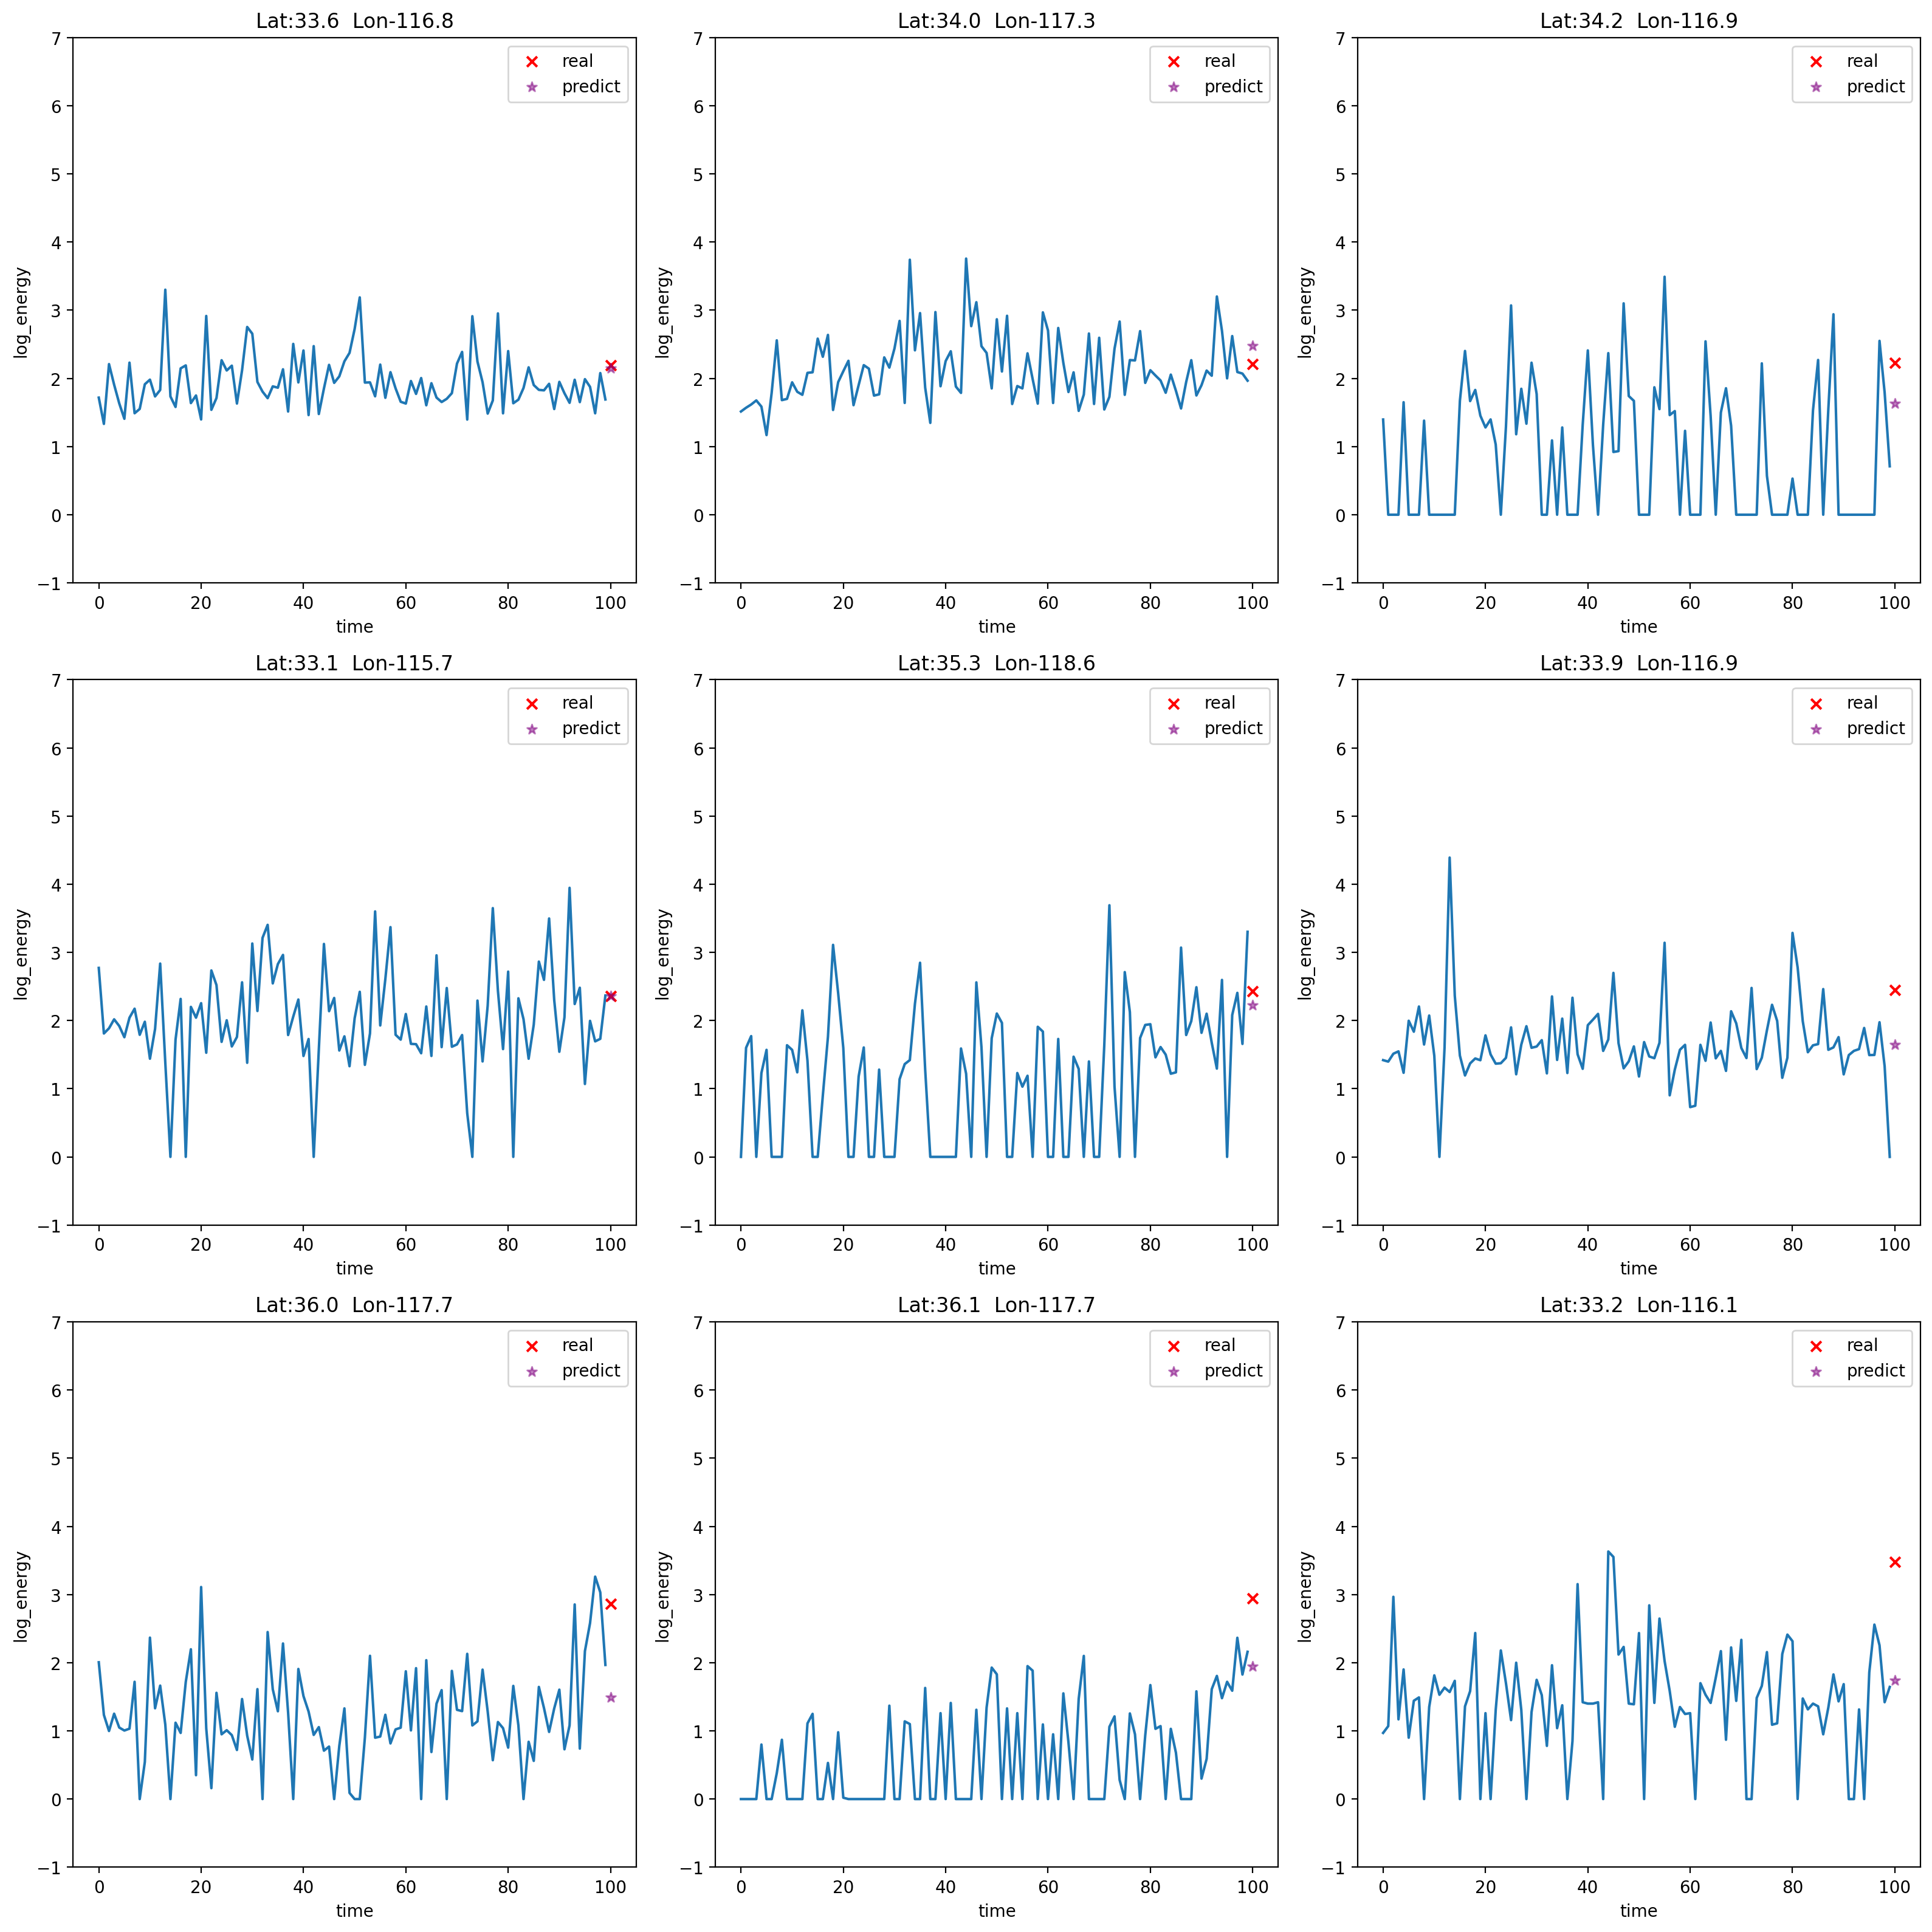

In [9]:
plt.figure(figsize=(16,16),dpi=200)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(range(len(earthquake_history_topk[:,i])),earthquake_history_topk[:,i])
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(earthquake_future_topk[:,i])),earthquake_future_topk[:,i],c='r',marker='x',label='real')
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(energy_predict[:,i])),energy_predict[:,i],c='purple',marker='*',label='predict',alpha=0.5)
    plt.title('Lat:'+str(earthquake_location_topk[i][0])+'  Lon'+str(earthquake_location_topk[i][1]))
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('log_energy')
    plt.ylim(-1,7)
plt.tight_layout()
plt.show()

In [10]:
energy_predict_all = []
earthquake_future_all = []
energy_history_all = []
earthquake_happen_all = []
with torch.no_grad():
    for batch in use_loader:
        predictions = model.predict_step(batch, 0)
        energy_predict_all.append(predictions['energy_predict'])
        earthquake_future_all.append(predictions['log_energy_future'])
        energy_history_all.append(batch['log_energy_history'])
        earthquake_happen_all.append(batch['earthquake_happen'])
energy_predict_all = torch.cat(energy_predict_all)
earthquake_future_all = torch.cat(earthquake_future_all)
energy_history_all = torch.cat(energy_history_all)
earthquake_happen_all = torch.cat(earthquake_happen_all)


In [34]:
def calculate_earthquake_threshold(energy_predict_all,threshold):
    earthquake_happen_predict = (energy_predict_all>threshold)
    return earthquake_happen_predict

def plot_confusion_matrix(energy_predict_all, earthquake_happen_all, threshold = 3.29):
    """
    计算并绘制混淆矩阵，同时打印各类评估指标。
    
    Args:
        energy_predict_all: 预测的能量值 (torch.Tensor)
        earthquake_happen_all: 地震发生的真实标签 (torch.Tensor)
    Returns:
        energy_predict: numpy 数组，预测的能量值
        earthquake_target: numpy 数组，地震发生的真实标签
    """
    labels = [0, 1]
    energy_predict = energy_predict_all.cpu().numpy().flatten()
    earthquake_target = earthquake_happen_all.cpu().numpy().flatten()

    # 将连续的预测值转为分类标签
    earthquake_happen_predict = calculate_earthquake_threshold(energy_predict, threshold=threshold)

    # 计算混淆矩阵
    confusion_matrix_result = confusion_matrix(earthquake_target, earthquake_happen_predict, labels=labels)

    # 提取混淆矩阵中的元素
    TP = confusion_matrix_result[1, 1]
    TN = confusion_matrix_result[0, 0]
    FP = confusion_matrix_result[0, 1]
    FN = confusion_matrix_result[1, 0]

    # 计算各类指标
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
    TNR = TN / (FP + TN) if (FP + TN) > 0 else 0  # True Negative Rate
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    Error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    Aggregative_Score = (TPR + Precision + Accuracy) / 3

    # 绘制混淆矩阵
    sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predict')
    plt.ylabel('Real')
    plt.title('Confusion Matrix')

    # 打印指标
    print(f"TPR (Recall): {TPR:.2f}")
    print(f"TNR (Specificity): {TNR:.2f}")
    print(f"Precision: {Precision:.2f}")
    print(f"Accuracy: {Accuracy:.2f}")
    print(f"Error: {Error:.2f}")
    print(f"FPR: {FPR:.2f}")
    print(f"Aggregative Score: {Aggregative_Score:.2f}")

    # 显示混淆矩阵
    plt.show()
    
    return energy_predict, earthquake_target

TPR (Recall): 0.41
TNR (Specificity): 0.89
Precision: 0.01
Accuracy: 0.88
Error: 0.12
FPR: 0.11
Aggregative Score: 0.44


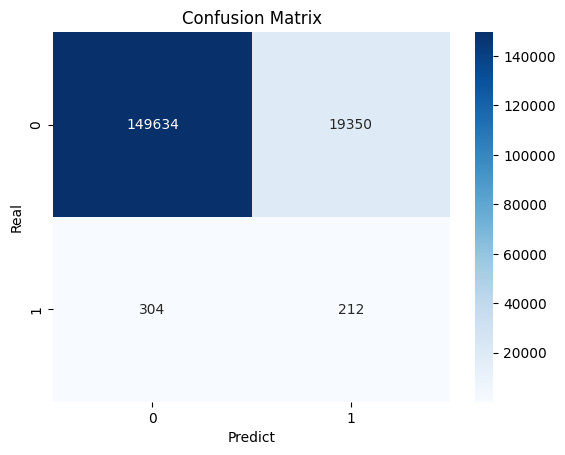

In [35]:
energy_predict,earthquake_target = plot_confusion_matrix(energy_predict_all,earthquake_happen_all,threshold=2.21)

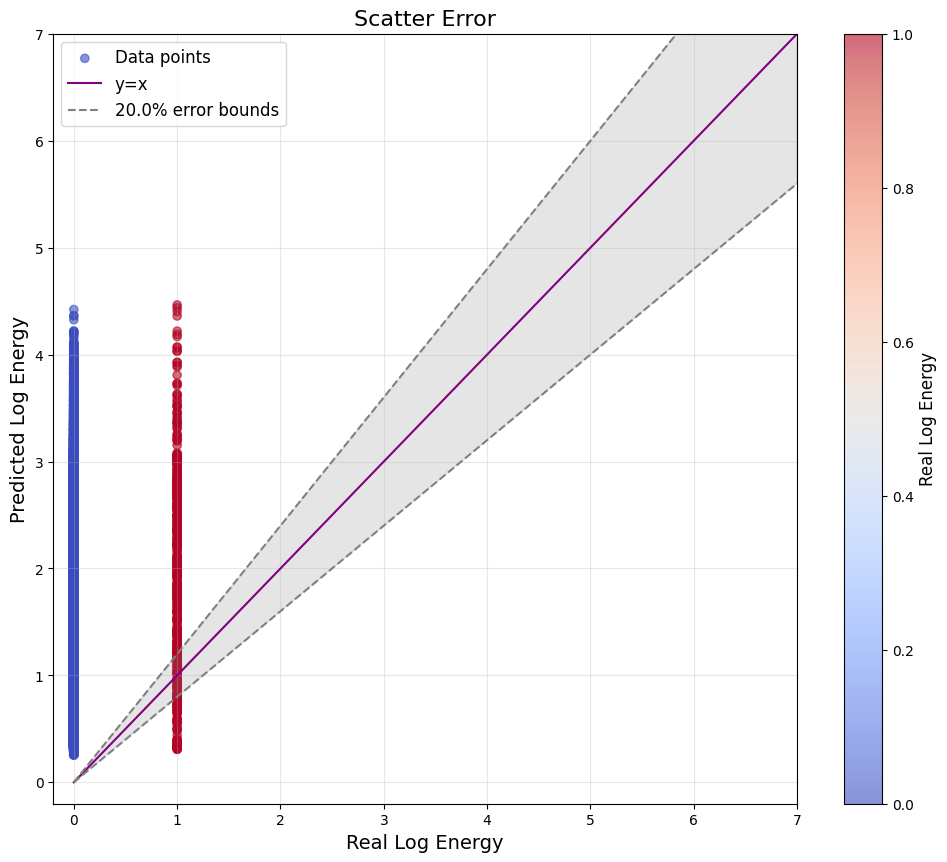

In [43]:
plot_error(energy_predict,earthquake_target,0.2)

In [37]:
energy_history_last = energy_history_all[:,-1,:,:].flatten().detach().cpu().numpy()

In [38]:
delta_energy_predict = energy_predict - energy_history_last
delta_energy_target = earthquake_target - energy_history_last

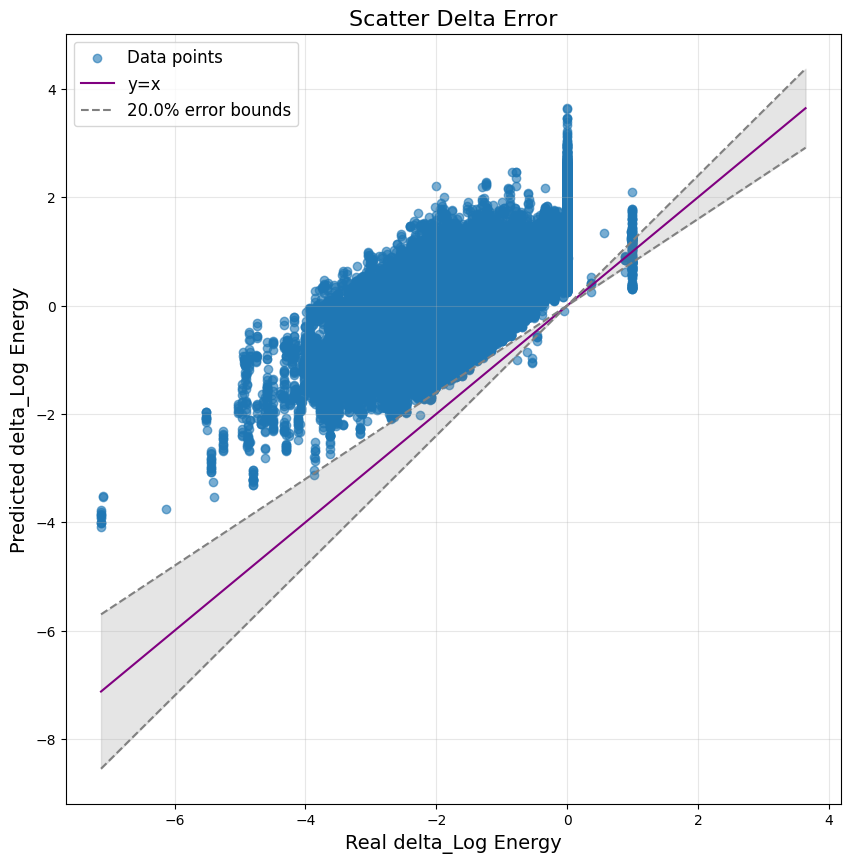

In [39]:
plot_delta_error(delta_energy_predict,delta_energy_target,0.2)

In [40]:
mse =np.power((energy_predict - earthquake_target),2).mean()
rmse = np.sqrt(mse)
nse = 1 - (np.sum(np.power((earthquake_target - energy_predict), 2)) / np.sum(np.power((earthquake_target - np.mean(earthquake_target)), 2)))
nnse = 1/(2-nse)
print("nnse:",nnse)
print('rmse:', rmse)
print('mse:', mse)

nnse: 0.0011811319545232987
rmse: 1.6020354
mse: 2.5665174


In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_curve_for_magnitude(energy_predict_all, earthquake_happen_all, thresholds_range=(0, 5)):
    """
    绘制 ROC 曲线并计算 AUC 值，同时打印最佳阈值。
    
    Args:
        energy_predict_all: 预测的能量值 (torch.Tensor)
        earthquake_happen_all: 地震发生的真实标签 (torch.Tensor)
        thresholds_range: 阈值范围 (tuple)，默认为 (0, 5)
    """
    # 转换为 numpy 数组
    energy_predict = energy_predict_all.cpu().numpy().flatten()
    earthquake_target = earthquake_happen_all.cpu().numpy().flatten()
    
    # 确保标签是二值的（0/1）
    assert set(np.unique(earthquake_target)) <= {0, 1}, "地震发生的真实标签必须是二值的（0 和 1）"

    # 计算 ROC 曲线
    fpr, tpr, thresholds = roc_curve(earthquake_target, energy_predict)
    
    # 计算 AUC 值
    roc_auc = auc(fpr, tpr)

    # 计算最佳阈值
    # 使用 Youden's J statistic: J = TPR - FPR
    J_statistic = tpr - fpr
    best_threshold_index = np.argmax(J_statistic)
    best_threshold = thresholds[best_threshold_index]
    
    # 绘制 ROC 曲线
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')  # 对角线
    plt.scatter(fpr[best_threshold_index], tpr[best_threshold_index], color='red', label=f'Best Threshold = {best_threshold:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Thresholds in Range {thresholds_range}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"AUC: {roc_auc:.2f}")
    print(f"Best Threshold: {best_threshold:.2f}")

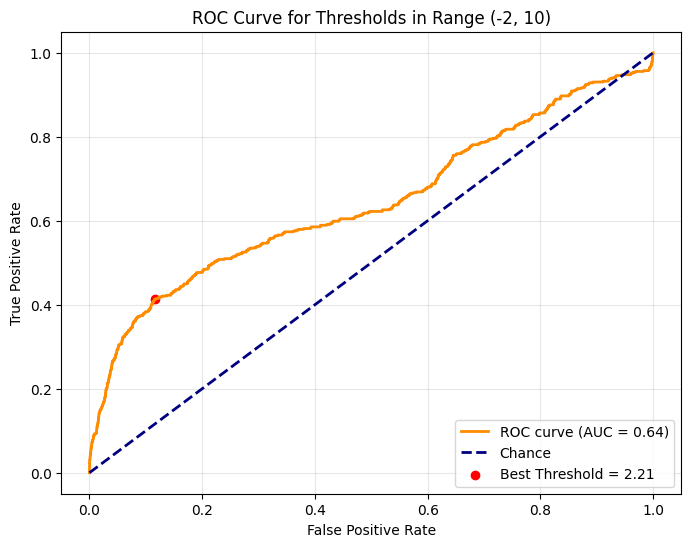

AUC: 0.64
Best Threshold: 2.21


In [42]:
plot_roc_curve_for_magnitude(energy_predict_all, earthquake_happen_all, thresholds_range=(-2, 10))